In [1]:
# -*- coding: utf-8 -*-
"""
@author: Rasjied O_o
"""
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# %% meta-data
informatie = fits.getheader('m44_1-0004_g.fit')
print(informatie)

SIMPLE  =                    T                                                  BITPIX  =                   16 /8 unsigned int, 16 & 32 int, -32 & -64 real     NAXIS   =                    2 /number of axes                                  NAXIS1  =                 4096 /fastest changing axis                           NAXIS2  =                 4096 /next to fastest changing axis                   BSCALE  =   1.0000000000000000 /physical = BZERO + BSCALE*array_value           BZERO   =   32768.000000000000 /physical = BZERO + BSCALE*array_value           DATE-OBS= '2026-03-04T21:25:05.30' /YYYY-MM-DDThh:mm:ss observation, UT         EXPTIME =   60.000000000000000 /Exposure time in seconds                        EXPOSURE=   60.000000000000000 /Exposure time in seconds                        SET-TEMP=  -10.000000000000000 /CCD temperature setpoint in C                   CCD-TEMP=  -10.062500000000000 /CCD temperature at start of exposure in C       XPIXSZ  =   9.0000000000000000 /Pixel Wi

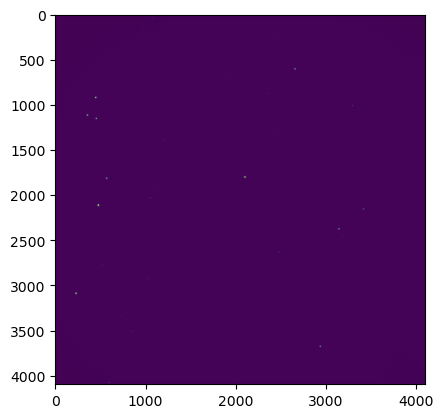

In [3]:
# %% data inladen en zichtbaar maken

data_file = fits.getdata('m44_1-0004_g.fit')
plt.imshow(data_file)
plt.show()

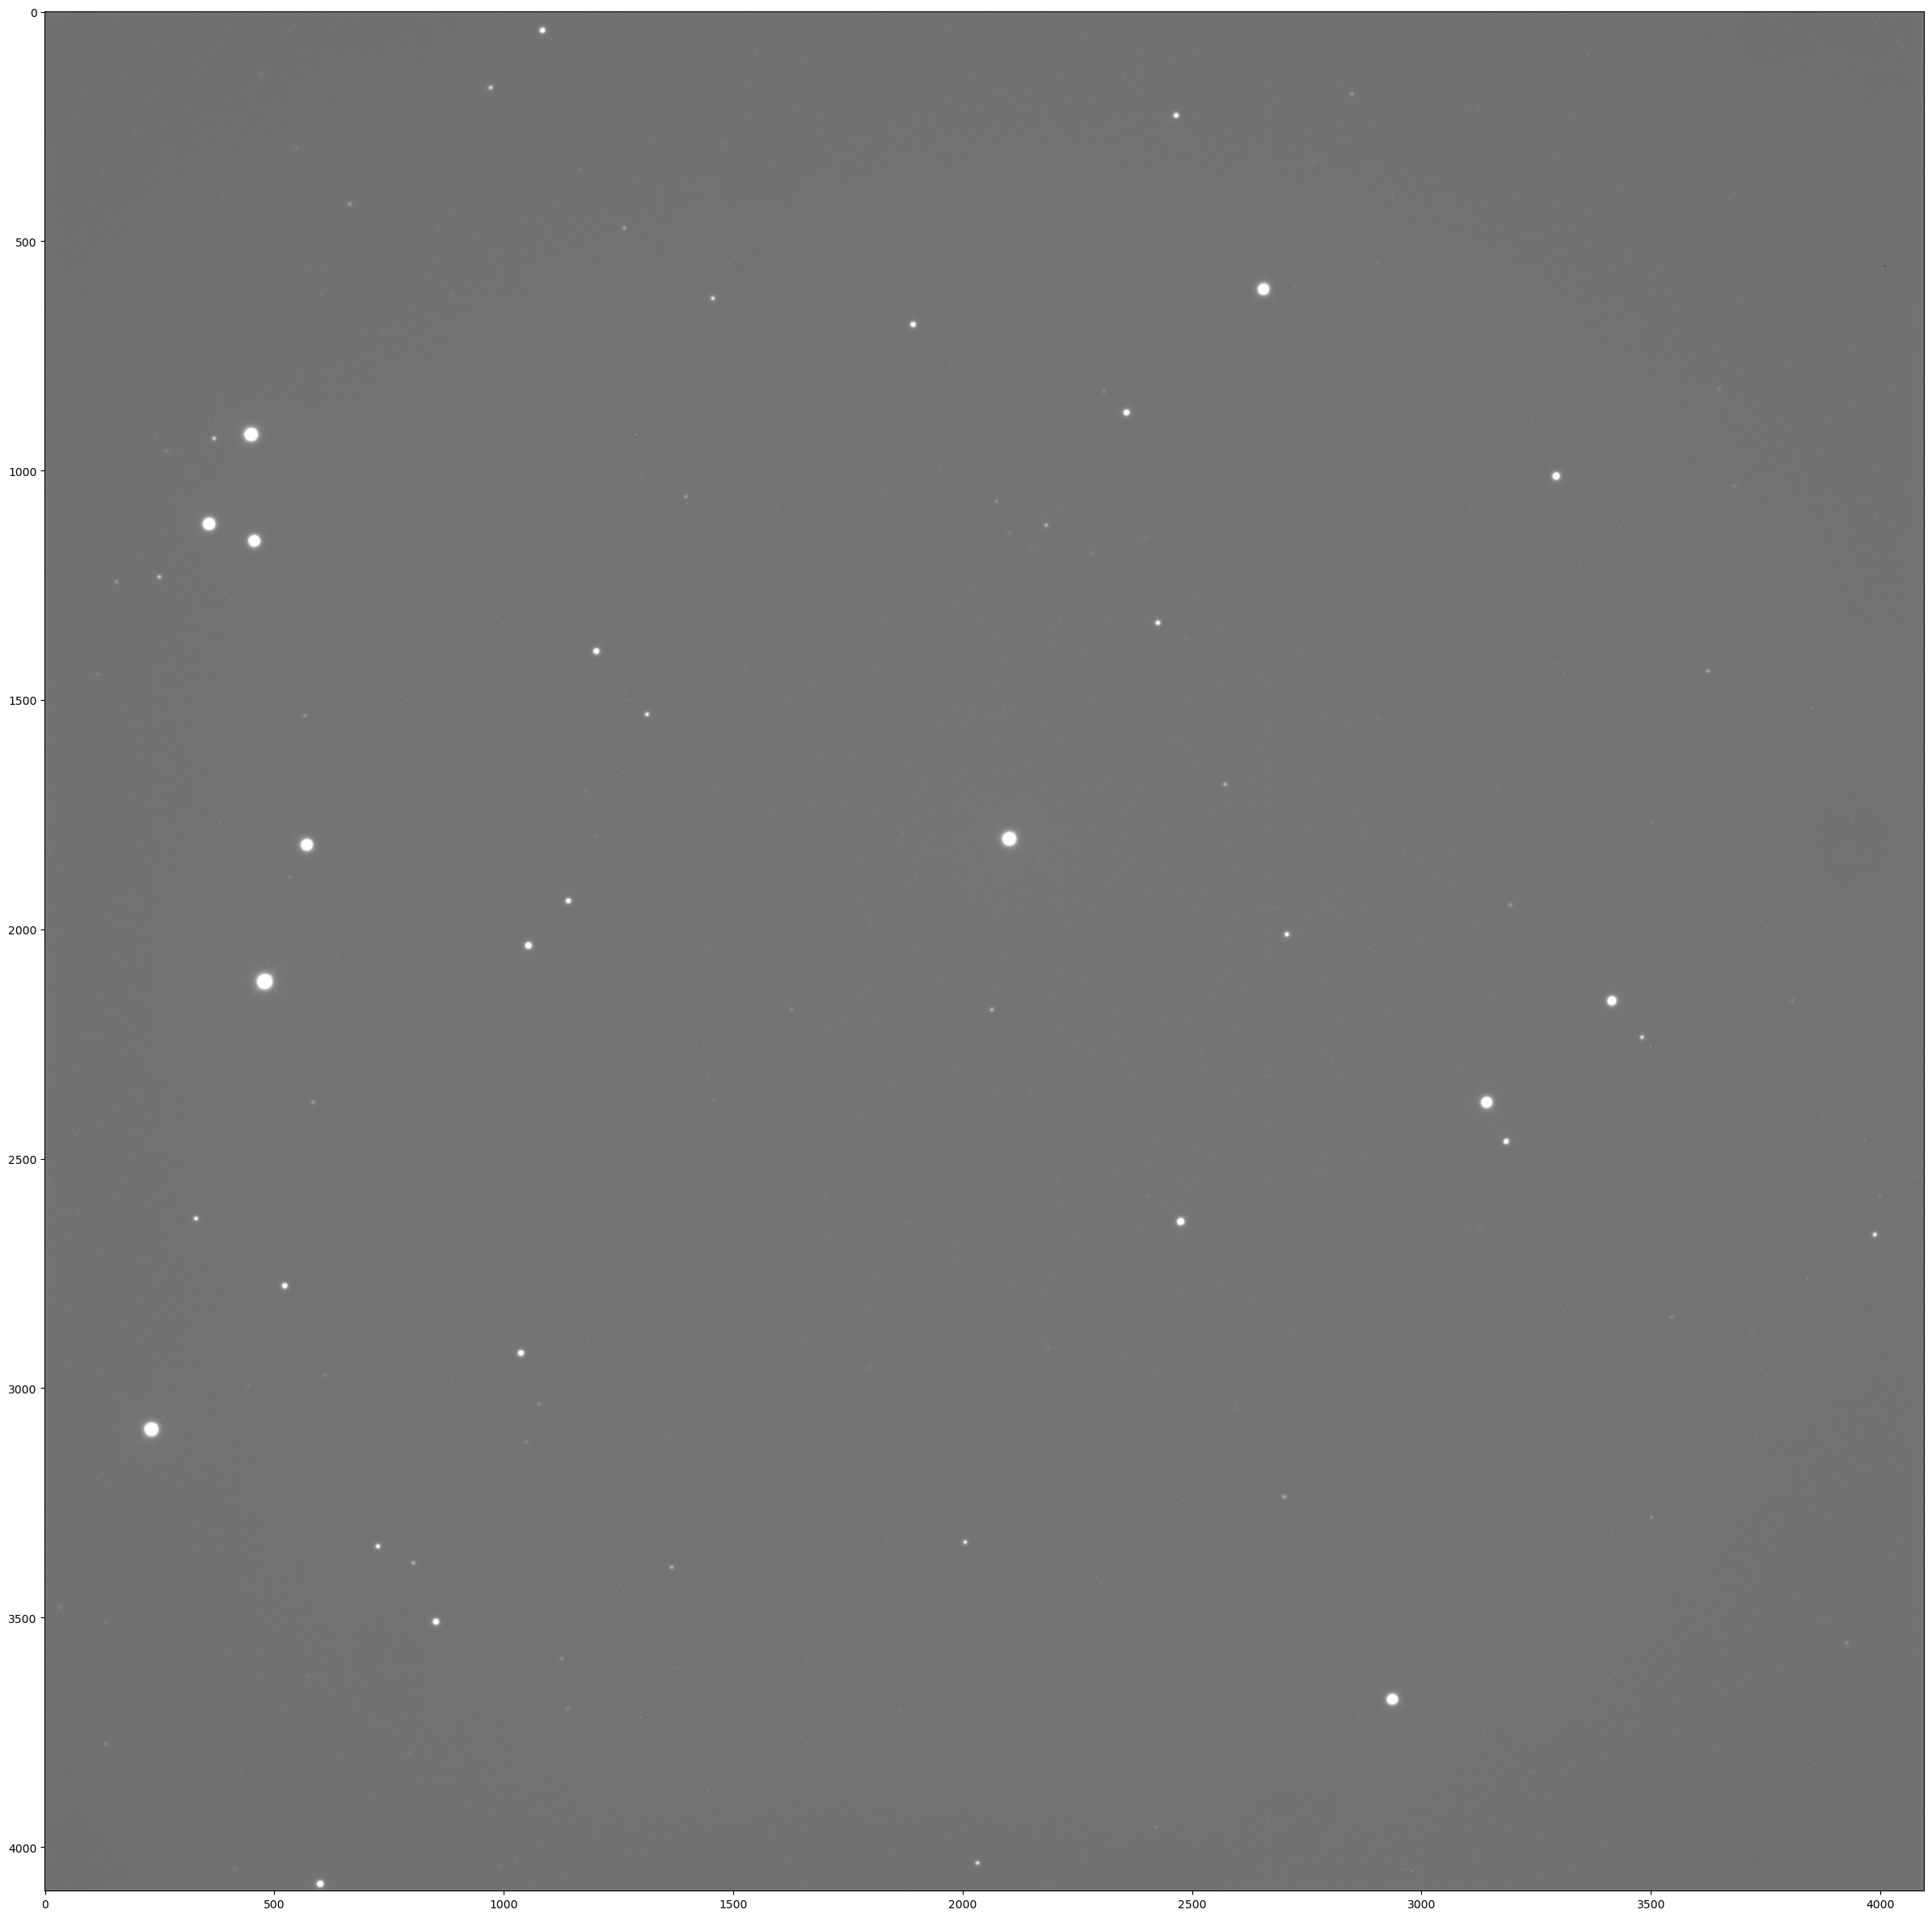

In [4]:
# %% Data beter zichtbaar maken: speel een beetje met de waarden voor vmin en vmax

plt.figure(figsize = (30,45))
plt.imshow(data_file, vmin = 300, vmax= 5000, cmap= 'gray')
plt.show()

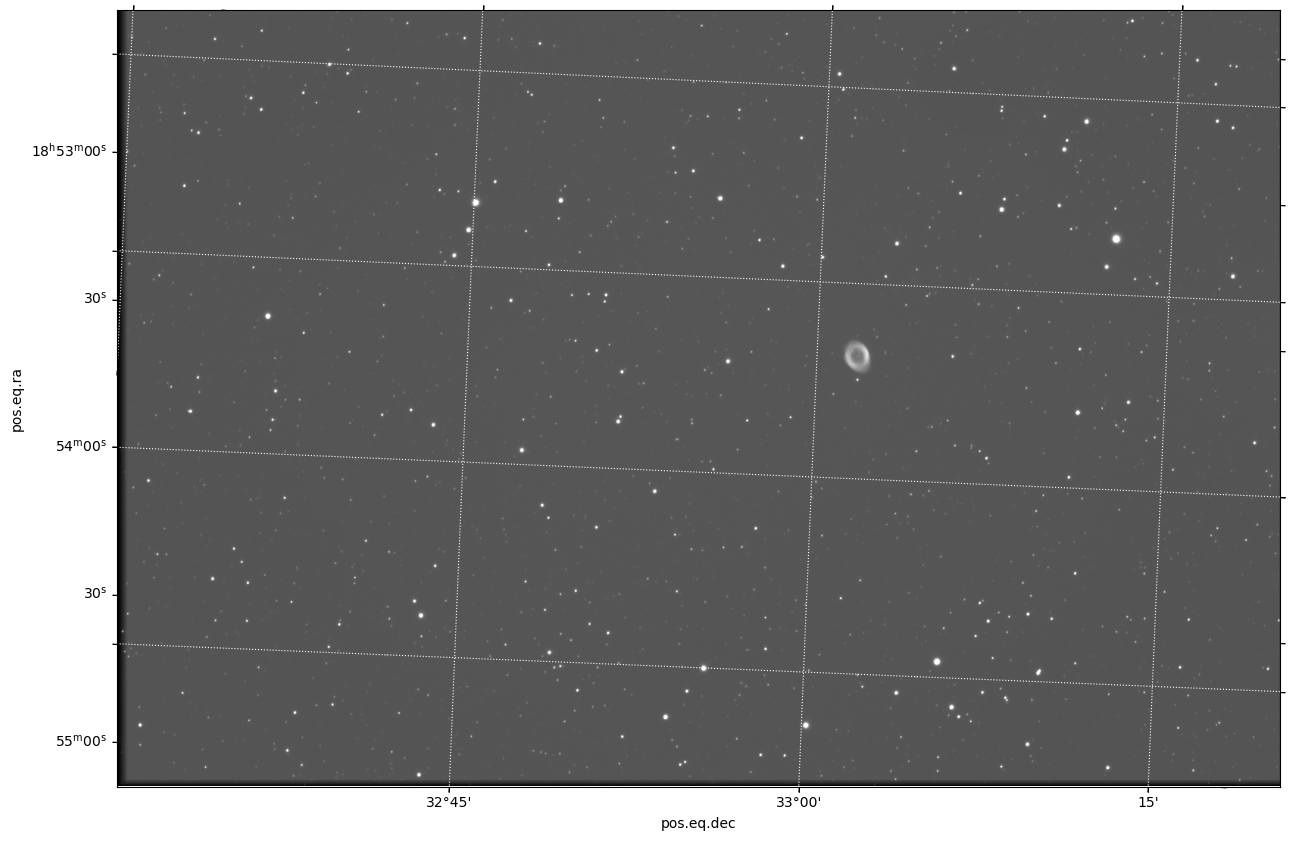

In [6]:
# %%Hemelcoordinaten uit de fits file plotten 
# (Let op: dit werkt alleen als je fits-file is 'geplatesolved'. Upload daarvoor je file op nova.astrometry.net en download dan het resultaat new-image.fits)

from astropy.wcs import WCS
plt.figure(figsize = (15,30))
wcs = WCS(informatie)
ax = plt.subplot(projection=wcs, label='overlays')
ax.imshow(data_file, vmin = 300, vmax= 5000, origin='lower', cmap= 'gray')
overlay = ax.get_coords_overlay('fk5')
overlay.grid(color='white', ls='dotted')
overlay[0].set_axislabel('Right Ascension (J2000)')
overlay[1].set_axislabel('Declination (J2000)')
plt.show()

0d25m18.84s


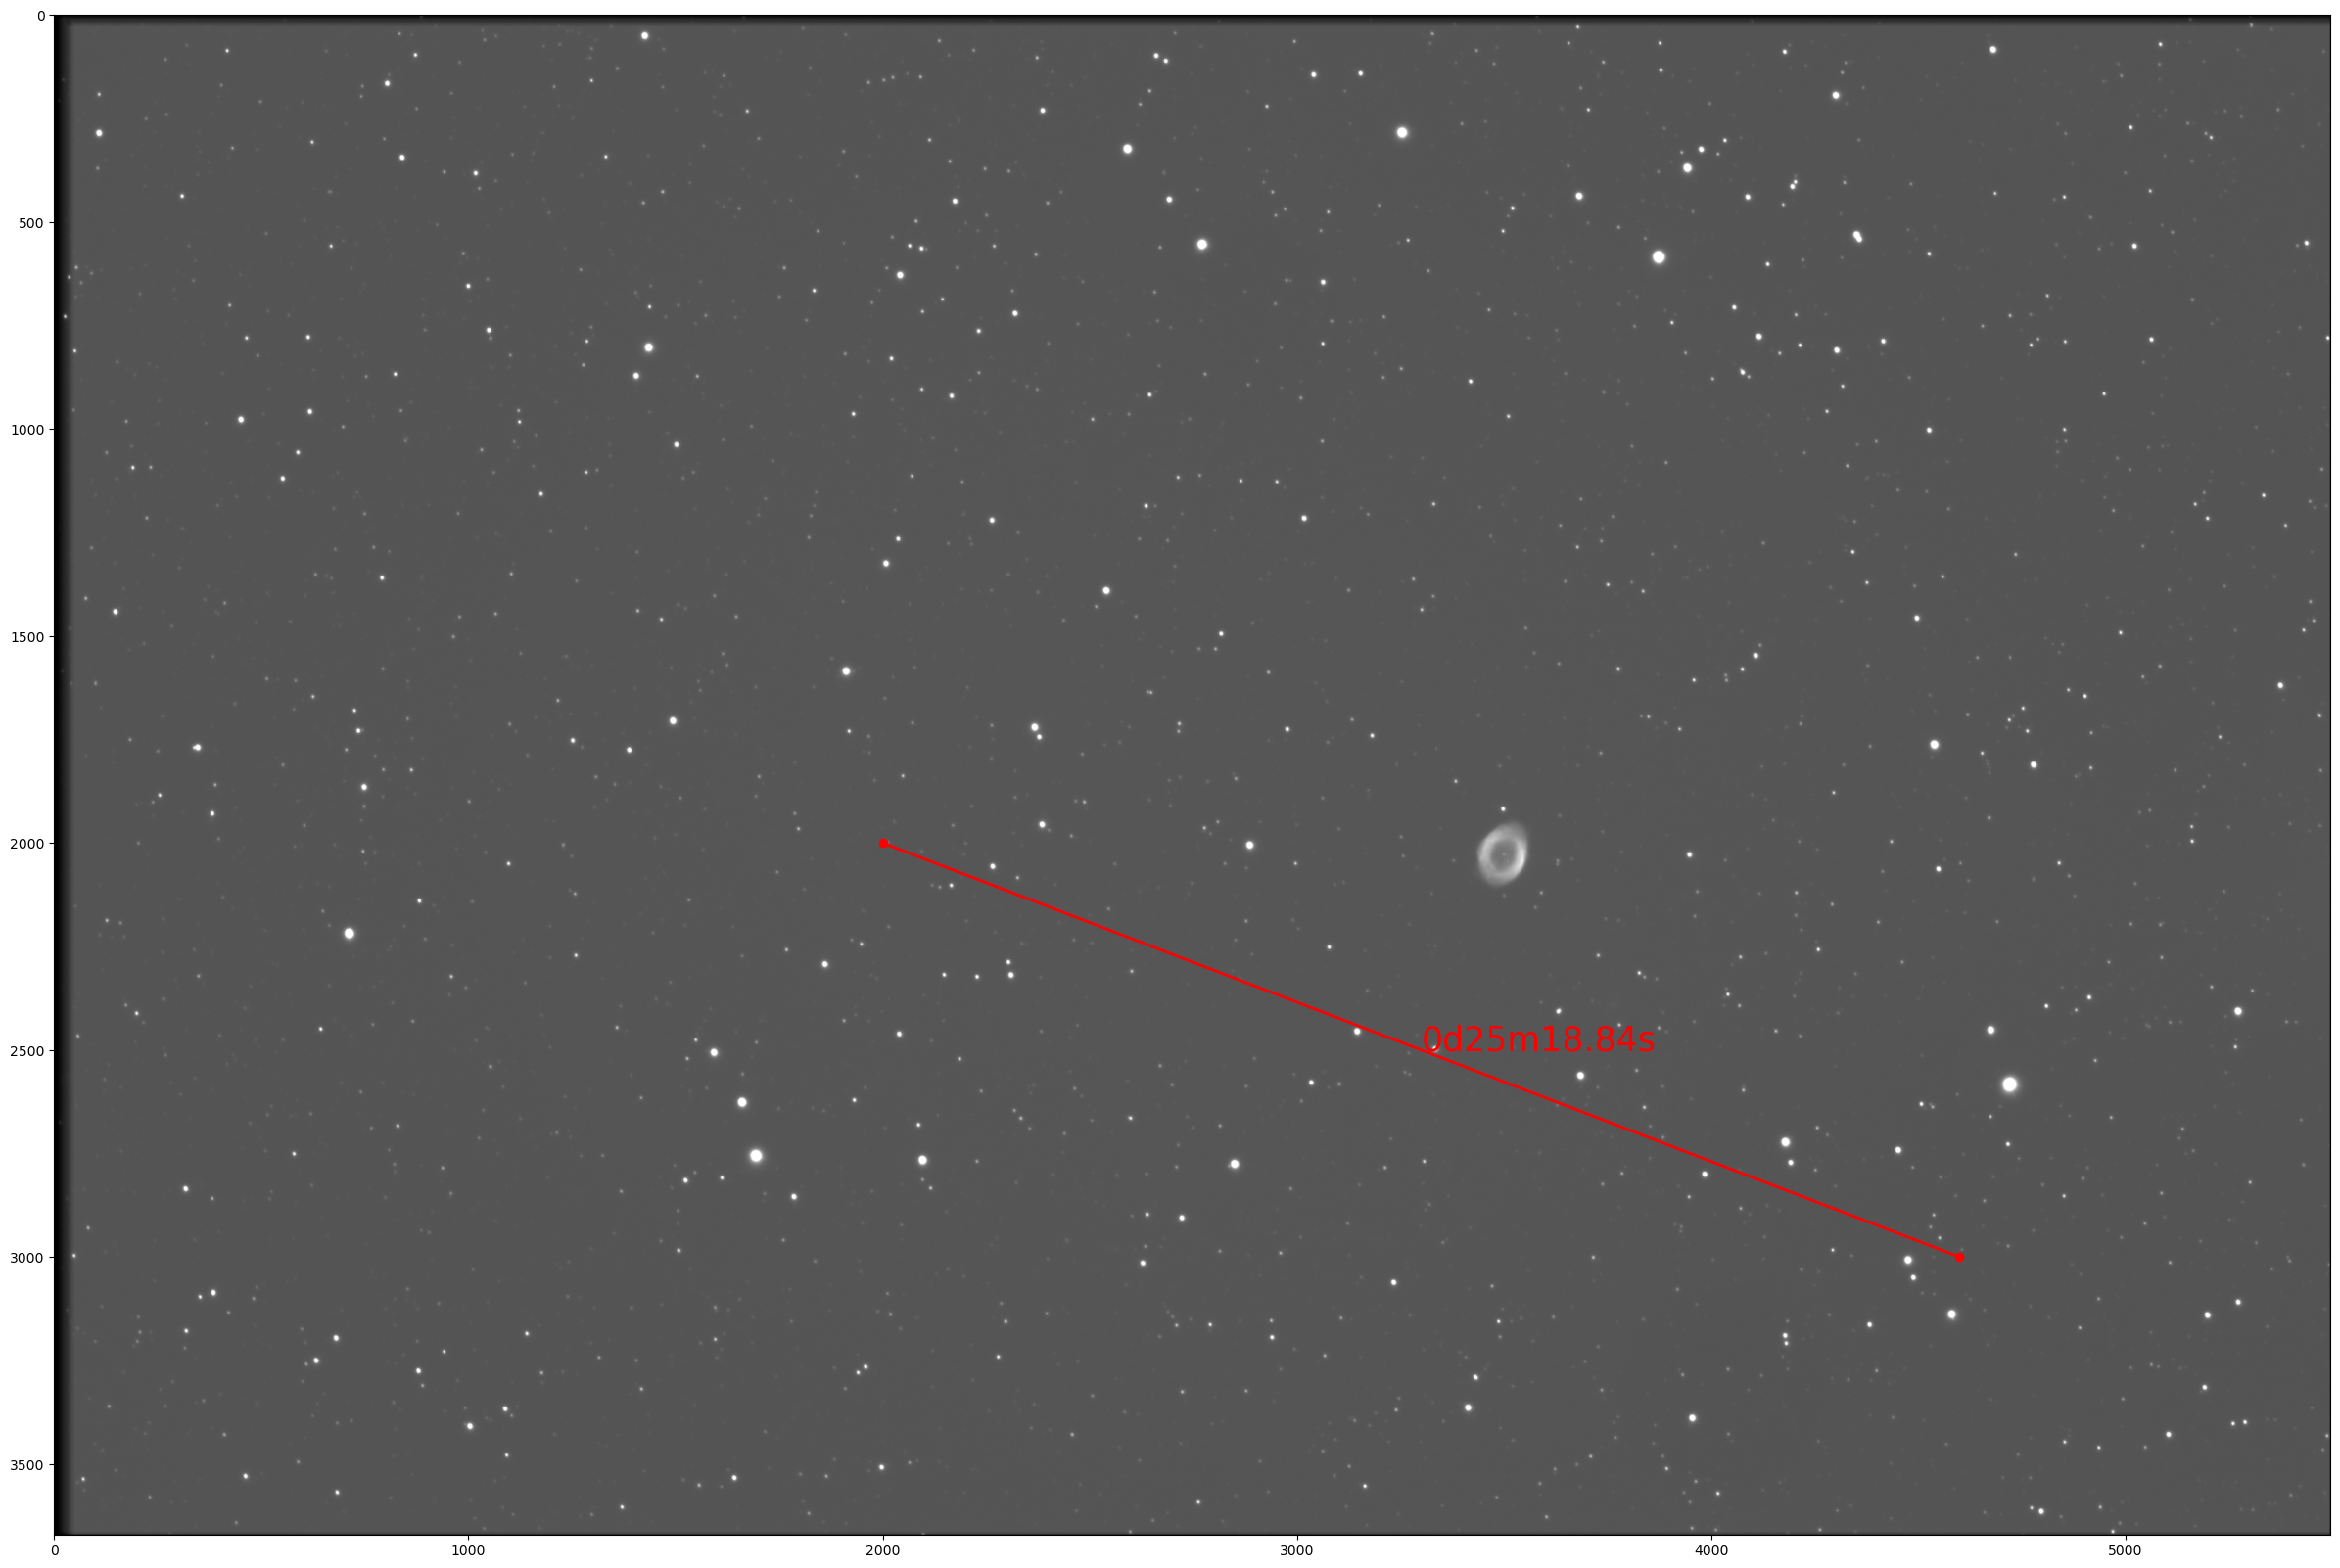

In [7]:
# %% hoekafstanden meten tussen 2 punten (mbv WCS-coordinated):

punt1_x = 2000
punt1_y = 2000
sky_1 = wcs.pixel_to_world(punt1_x, punt1_y)

punt2_x = 4600
punt2_y = 3000
sky_2 = wcs.pixel_to_world(punt2_x, punt2_y)

distance = np.round(sky_1.separation(sky_2),4)
print(distance)

plt.figure(figsize = (30,45))
plt.imshow(data_file, vmin = 300, vmax= 5000, cmap= 'gray')
plt.plot([punt1_x, punt2_x], [punt1_y, punt2_y], marker = 'o', c='red', lw=2)
plt.text((punt1_x+punt2_x)/2, (punt1_y+punt2_y)/2, distance, fontsize=25, c ='red')
plt.show()

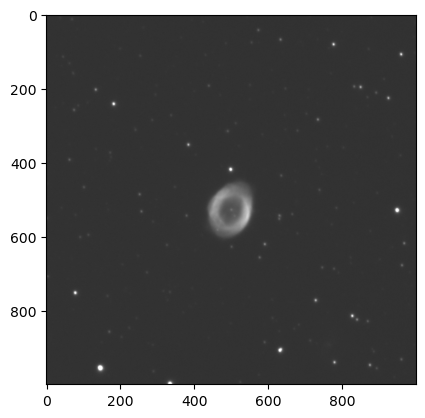

In [8]:
# %% een crop maken van je foto met 3000 < x < 4000 en 1500 < y < 2500

data_cropped = data_file[1500:2500,3000:4000]
plt.imshow(data_cropped, vmin = 1000, vmax= 5500, cmap= 'gray')
plt.show()

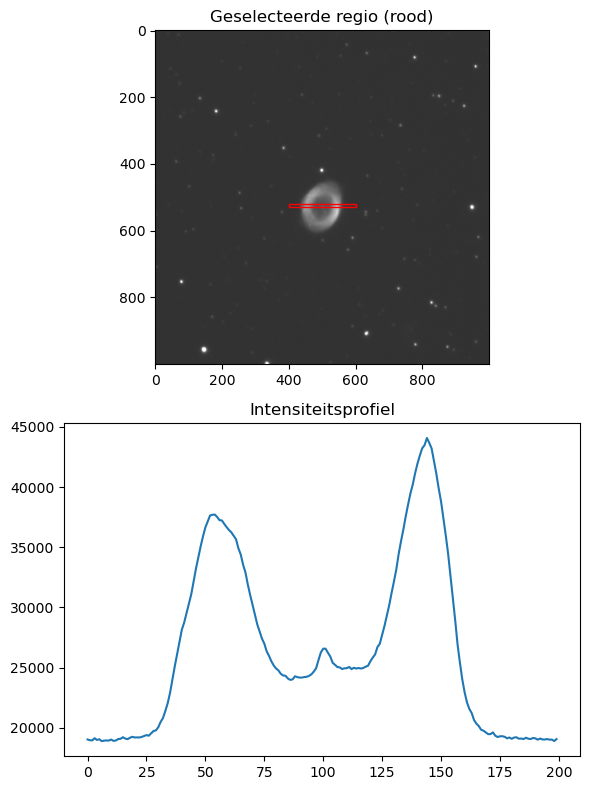

In [9]:
# %% Een intensiteitsplotje maken door de nevel heen:
    
from matplotlib.patches import Rectangle    

y_min = 520
y_max = 530

x_min = 400
x_max = 600

regio = data_cropped[y_min:y_max,x_min:x_max]
intensiteit = np.sum(regio, axis =0)

fig, axes = plt.subplots(2, 1, figsize=(6, 8))  # Twee subplots onder elkaar

# Eerste subplot: Beeld met rechthoek
axes[0].imshow(data_cropped, vmin=1000, vmax=5500, cmap='gray')
axes[0].add_patch(Rectangle((x_min, y_min), x_max - x_min, y_max - y_min,
                            edgecolor='red', facecolor='none', lw=1))
axes[0].set_title("Geselecteerde regio (rood)")

# Tweede subplot: Intensiteitsprofiel
axes[1].plot(intensiteit)
axes[1].set_title("Intensiteitsprofiel")

plt.tight_layout()  # Zorgt voor nette schikking van de subplots
plt.show()

In [ ]:
# %% Flux meten (zie https://photutils.readthedocs.io/en/latest/user_guide/aperture.html# )
# misschien moet je eerst photutils installeren ('pip install photutils')


from photutils.aperture import CircularAnnulus, CircularAperture, aperture_photometry, ApertureStats

data_fotometrie = data_cropped[380:600,400:700]

# 2 posities definieren:

positions = [(98, 39),(235, 55)]
aperture = CircularAperture(positions, r=7)
annulus_aperture = CircularAnnulus(positions, r_in=15, r_out=25)


# plaatje maken

plt.imshow(data_fotometrie, vmin = 1000, vmax= 5500, cmap= 'gray')

ap_patches = aperture.plot(color='yellow', lw=2,
                           label='Photometry aperture')
ann_patches = annulus_aperture.plot(color='red', lw=2,
                                    label='Background annulus')
handles = (ap_patches[0], ann_patches[0])
plt.legend(loc=(0.17, 0.05), facecolor='#458989', labelcolor='white',
           handles=handles, prop={'weight': 'bold', 'size': 6})
plt.show()

In [ ]:
phot_table = aperture_photometry(data_fotometrie, aperture)

aperstats = ApertureStats(data_fotometrie, annulus_aperture)
bkg_mean = aperstats.mean
aperture_area = aperture.area_overlap(data_fotometrie)
total_bkg = bkg_mean * aperture_area

# %% Fotometrie


calibration_constant  = 26.57
phot_bkgsub = phot_table['aperture_sum'] - total_bkg
phot_table['total_bkg'] = total_bkg
phot_table['aperture_sum_bkgsub'] = phot_bkgsub
phot_table['instrumental magnitude'] = -2.5*np.log10(phot_bkgsub)
phot_table['calibrated magnitude'] = -2.5*np.log10(phot_bkgsub) + calibration_constant
for col in phot_table.colnames:
    phot_table[col].info.format = '%.8g'  # for consistent table output
print(phot_table)

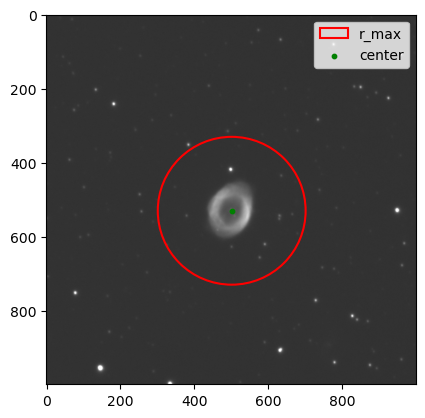

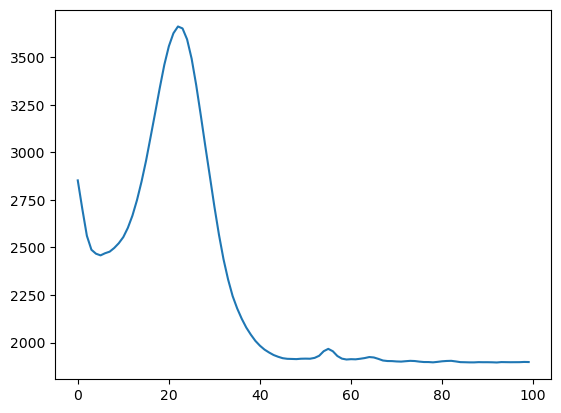

In [10]:
# Verondersteld dat 'data_cropped' al gedefinieerd is
height, width = data_cropped.shape
center = (501, 530)

# Bereken radiale afstand
y, x = np.indices((height, width))
r = np.sqrt((x - center[0]) ** 2 + (y - center[1]) ** 2)

# Definieer radiale bins
r_max = 200
num_bins = 100
bin_edges = np.linspace(0, r_max, num_bins + 1)
bin_indices = np.digitize(r, bin_edges) - 1

fig, ax = plt.subplots()
im = ax.imshow(data_cropped, vmin=1000, vmax=5500, cmap='gray', origin='upper')
circle_outer = plt.Circle(center, r_max, color='red', fill=False, linewidth=1.5, label = 'r_max')
ax.add_patch(circle_outer)
ax.scatter(center[0], center[1], c='green', s=10, label = 'center')
plt.legend()
plt.show()

# finding the mean flux values for each bin
bin_means = np.array([data_cropped[bin_indices == i].mean() if np.any(bin_indices == i) else 0 for i in range(num_bins)])

# diving each bin flux sum by its area
bin_areas = np.pi * (bin_edges[:-1]**2-bin_edges[1:]**2 )
bin_areas /= bin_means

plt.plot(bin_means)
# plt.yscale('log')
plt.show()


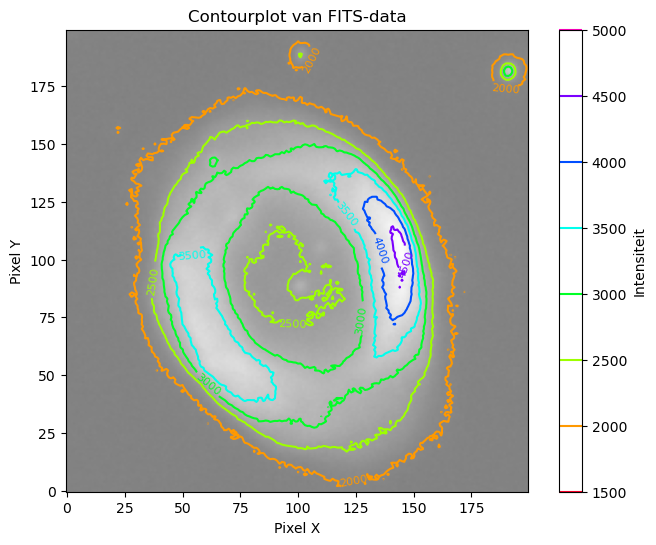

In [11]:
# %% contourplot

super_crop = data_cropped[440:640,400:600]

fig, ax = plt.subplots(figsize=(8, 6))
contours = ax.contour(super_crop, levels=5, cmap="gist_rainbow", linewidths=1.5)  # 10 contourlijnen
ax.clabel(contours, inline=True, fontsize=8, fmt="%.0f")  # Labels op contourlijnen
ax.imshow(super_crop, cmap="gray", origin="lower", alpha=0.5)  # Transparante achtergrond

plt.colorbar(contours, ax=ax, label="Intensiteit")
ax.set_title("Contourplot van FITS-data")
ax.set_xlabel("Pixel X")
ax.set_ylabel("Pixel Y")
plt.show()